# Libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

df = pd.read_csv('finance_economics_dataset.csv')

## Data Filtering
### Type

In [2]:
df.describe()
df.columns
df.dtypes
df.isnull().sum() 
df.duplicated().sum()

,Open Price,Close Price,Daily High,Daily Low,Trading Volume,GDP Growth (%),Inflation Rate (%),Unemployment Rate (%),Interest Rate (%),Consumer Confidence Index,...,Forex USD/EUR,Forex USD/JPY,Crude Oil Price (USD per Barrel),Gold Price (USD per Ounce),Real Estate Index,Retail Sales (Billion USD),Bankruptcy Rate (%),Mergers & Acquisitions Deals,Venture Capital Funding (Billion USD),Consumer Spending (Billion USD)
count,3000.000000,3000.000000,3000.000000,3000.00000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,2982.094607,2981.249173,3018.887777,2944.32975,5.033864e+08,2.608903,5.096830,8.663787,5.218237,85.036000,...,1.146113,115.115233,85.539953,1655.167877,300.554457,5099.546667,5.007413,24.598667,49.955197,7551.278000
std,1151.862689,1151.783841,1151.683485,1151.83490,2.859004e+08,4.287337,2.910513,3.737536,2.726115,20.224829,...,0.201128,20.111351,37.847063,492.177706,114.601328,2898.714108,2.866466,14.301344,28.722592,4203.705678
min,1000.050000,954.520000,1012.130000,917.17000,1.636024e+06,-5.000000,0.010000,2.000000,0.500000,50.000000,...,0.800000,80.010000,20.040000,800.160000,100.130000,107.000000,0.010000,0.000000,0.100000,101.000000
25%,1994.982500,1997.425000,2035.952500,1955.39750,2.545224e+08,-1.012500,2.607500,5.450000,2.890000,68.000000,...,0.980000,98.267500,52.590000,1226.737500,202.370000,2503.750000,2.570000,12.000000,25.762500,3950.750000
50%,2970.780000,2977.180000,3006.520000,2939.24500,5.033710e+08,2.725000,5.110000,8.710000,5.250000,86.000000,...,1.140000,114.795000,85.080000,1666.060000,299.885000,5123.500000,5.060000,25.000000,49.840000,7610.000000
75%,3974.690000,3982.082500,4015.217500,3934.08750,7.537963e+08,6.242500,7.600000,11.882500,7.492500,103.000000,...,1.320000,132.455000,119.150000,2080.730000,399.137500,7616.250000,7.482500,37.000000,74.825000,11148.750000
max,4998.230000,5034.130000,5076.190000,4977.06000,9.999771e+08,10.000000,10.000000,15.000000,10.000000,119.000000,...,1.500000,149.960000,149.870000,2499.660000,499.920000,9998.000000,10.000000,49.000000,99.990000,14990.000000


Index(['Date', 'Stock Index', 'Open Price', 'Close Price', 'Daily High',
       'Daily Low', 'Trading Volume', 'GDP Growth (%)', 'Inflation Rate (%)',
       'Unemployment Rate (%)', 'Interest Rate (%)',
       'Consumer Confidence Index', 'Government Debt (Billion USD)',
       'Corporate Profits (Billion USD)', 'Forex USD/EUR', 'Forex USD/JPY',
       'Crude Oil Price (USD per Barrel)', 'Gold Price (USD per Ounce)',
       'Real Estate Index', 'Retail Sales (Billion USD)',
       'Bankruptcy Rate (%)', 'Mergers & Acquisitions Deals',
       'Venture Capital Funding (Billion USD)',
       'Consumer Spending (Billion USD)'],
      dtype='object')

Date                                      object
Stock Index                               object
Open Price                               float64
Close Price                              float64
Daily High                               float64
Daily Low                                float64
Trading Volume                             int64
GDP Growth (%)                           float64
Inflation Rate (%)                       float64
Unemployment Rate (%)                    float64
Interest Rate (%)                        float64
Consumer Confidence Index                  int64
Government Debt (Billion USD)              int64
Corporate Profits (Billion USD)            int64
Forex USD/EUR                            float64
Forex USD/JPY                            float64
Crude Oil Price (USD per Barrel)         float64
Gold Price (USD per Ounce)               float64
Real Estate Index                        float64
Retail Sales (Billion USD)                 int64
Bankruptcy Rate (%) 

Date                                     0
Stock Index                              0
Open Price                               0
Close Price                              0
Daily High                               0
Daily Low                                0
Trading Volume                           0
GDP Growth (%)                           0
Inflation Rate (%)                       0
Unemployment Rate (%)                    0
Interest Rate (%)                        0
Consumer Confidence Index                0
Government Debt (Billion USD)            0
Corporate Profits (Billion USD)          0
Forex USD/EUR                            0
Forex USD/JPY                            0
Crude Oil Price (USD per Barrel)         0
Gold Price (USD per Ounce)               0
Real Estate Index                        0
Retail Sales (Billion USD)               0
Bankruptcy Rate (%)                      0
Mergers & Acquisitions Deals             0
Venture Capital Funding (Billion USD)    0
Consumer Sp

0

### Date

In [3]:
df['Date'] = pd.to_datetime(df['Date']) # convert object to datetime

df['Date'].min(), df['Date'].max()
expect_range = pd.date_range(start=df['Date'].min(), end=df['Date'].max(), freq='D')
expect_range.difference(df['Date'])
df['Date'].duplicated().sum()


df.sort_values('Date', inplace=True) # in memory only
df.head(10)

(Timestamp('2000-01-01 00:00:00'), Timestamp('2008-03-18 00:00:00'))

DatetimeIndex([], dtype='datetime64[ns]', freq='D')

0

,Date,Stock Index,Open Price,Close Price,Daily High,Daily Low,Trading Volume,GDP Growth (%),Inflation Rate (%),Unemployment Rate (%),...,Forex USD/EUR,Forex USD/JPY,Crude Oil Price (USD per Barrel),Gold Price (USD per Ounce),Real Estate Index,Retail Sales (Billion USD),Bankruptcy Rate (%),Mergers & Acquisitions Deals,Venture Capital Funding (Billion USD),Consumer Spending (Billion USD)
0,2000-01-01,Dow Jones,2128.75,2138.48,2143.70,2100.55,2670411,-0.37,6.06,6.10,...,1.04,119.87,47.20,1052.34,390.23,2229,2.12,3,76.64,4589
1,2000-01-02,S&P 500,2046.82,2036.18,2082.83,2009.53,690220415,3.19,4.95,6.62,...,1.00,98.22,52.84,1957.73,346.23,4156,1.40,21,5.67,10101
2,2000-01-03,Dow Jones,1987.92,1985.26,2022.28,1978.37,315284661,5.54,9.13,2.60,...,0.83,80.13,78.80,2339.49,439.46,340,0.79,48,39.43,13665
3,2000-01-04,Dow Jones,4625.02,4660.47,4665.26,4595.46,13098297,10.00,3.77,2.20,...,0.95,149.15,28.18,1308.54,213.07,8456,4.22,16,12.83,5192
4,2000-01-05,S&P 500,1998.18,1982.18,2044.31,1966.44,385306746,1.53,2.20,8.20,...,1.43,113.71,92.20,2210.08,405.49,1596,2.21,34,86.37,10688
5,2000-01-06,S&P 500,2087.80,2124.76,2153.18,2085.18,82664194,1.42,6.08,3.24,...,1.39,140.00,60.23,2338.39,441.06,403,0.82,45,96.80,8613
6,2000-01-07,Dow Jones,4037.59,3996.40,4055.78,3948.97,653722138,7.64,6.24,4.52,...,0.92,138.80,29.30,1309.15,319.60,4874,9.55,31,32.63,1303
7,2000-01-08,NASDAQ,2798.96,2826.64,2864.47,2766.89,423890033,7.08,4.39,13.01,...,1.06,136.86,117.92,896.46,265.51,1011,7.33,37,98.89,3771
8,2000-01-09,Dow Jones,4106.84,4141.59,4154.46,4062.99,867172199,5.97,4.87,9.42,...,1.02,112.13,104.95,2358.55,479.46,5193,5.18,30,75.26,13164
9,2000-01-10,Dow Jones,1261.46,1229.64,1296.14,1195.84,174582201,1.95,9.60,10.24,...,0.90,142.71,123.15,1361.82,167.59,6147,7.43,24,0.22,13774


## Correlation
Adjust Parameters and Run All to see result

In [4]:
# Set parameters
SAMPLE_RATE = 'QE' # D, ME, QE, Y
THRESHOLD = 0.05

<Figure size 1400x1200 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation Matrix of Financial Features (QE)')

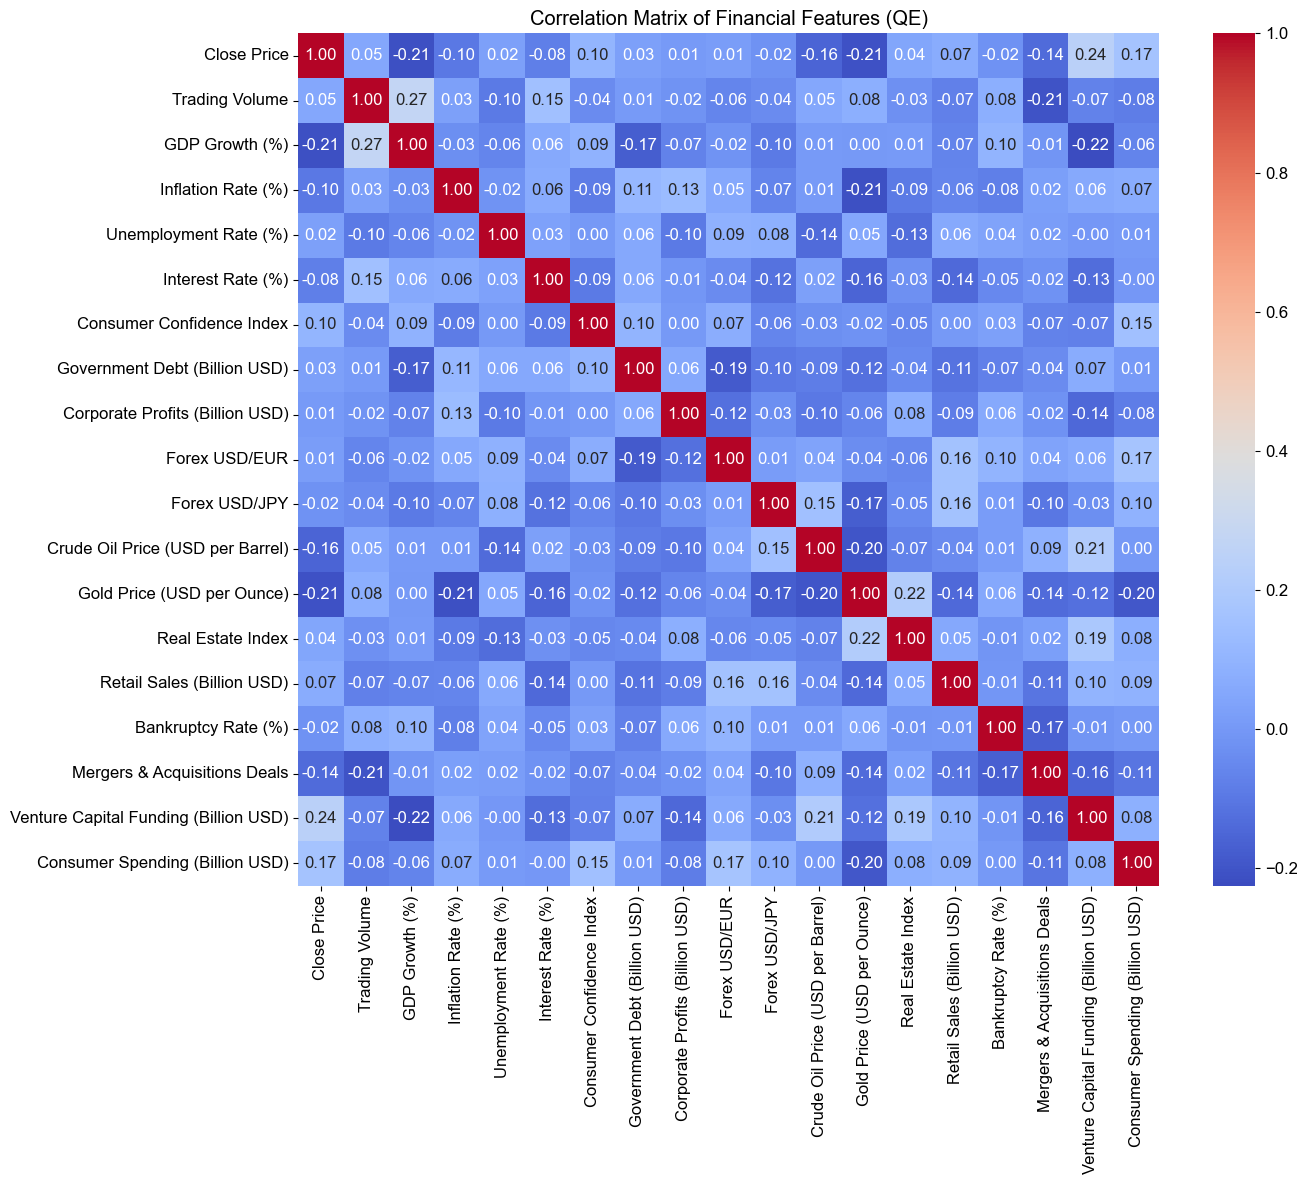

<Figure size 1400x1200 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation Matrix of Financial Features (QE, Threshold=0.05)')

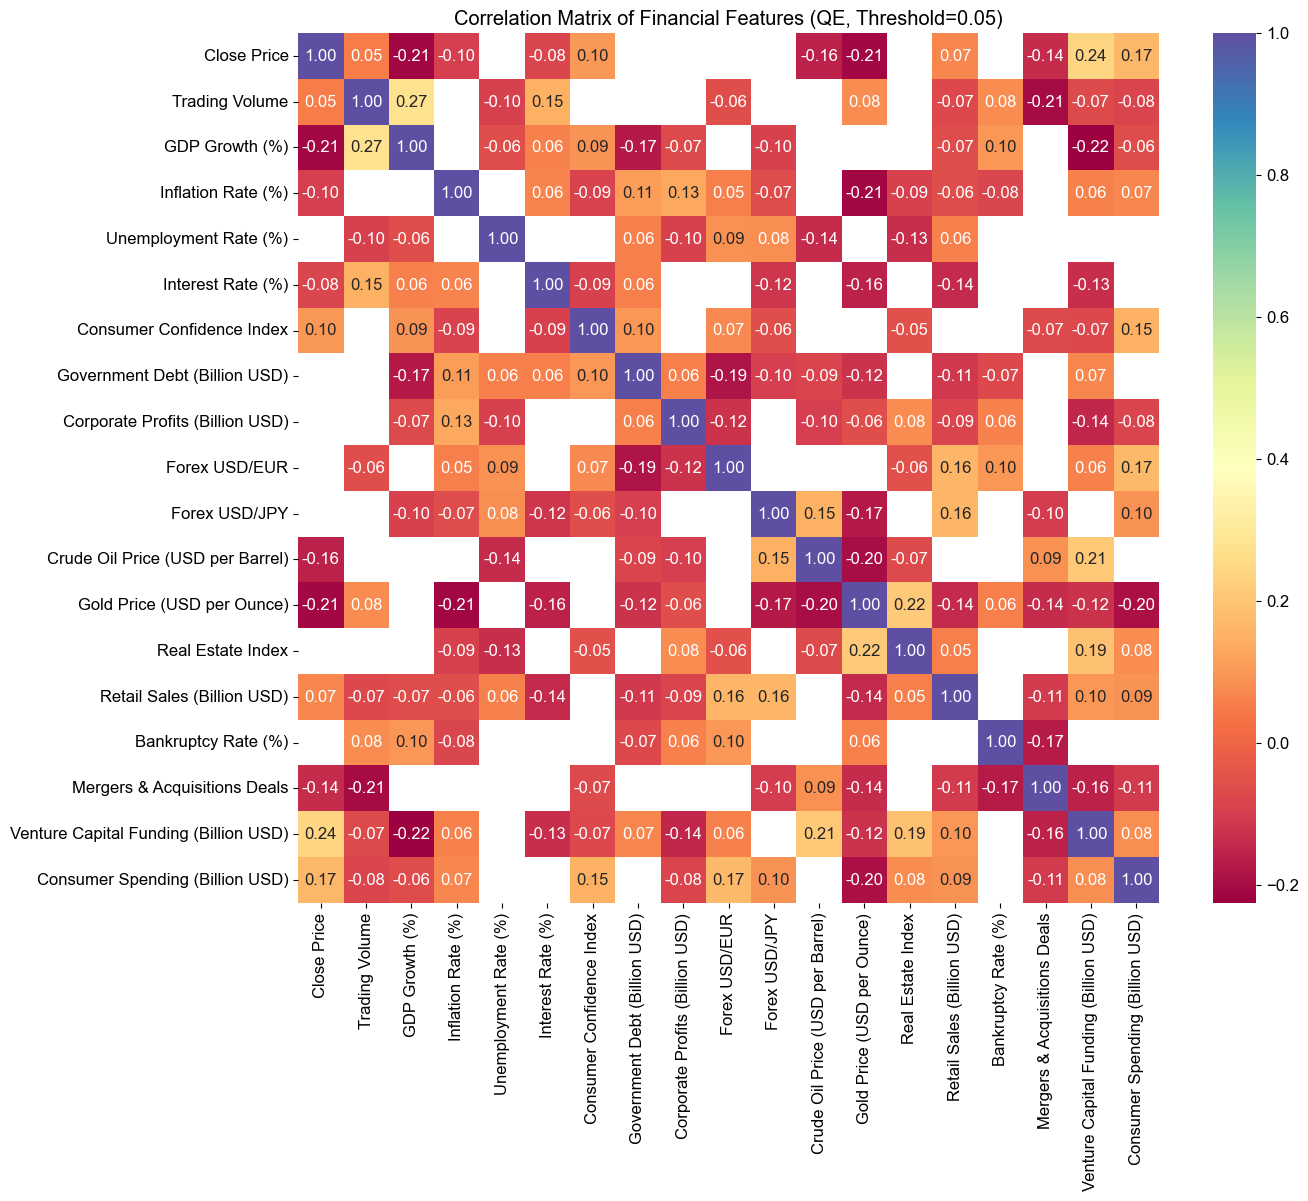

In [ ]:
#plot setting
plt.rcParams['font.family'] = 'Arial'   
plt.rcParams['font.size'] = 12  

df_corr = df.resample(SAMPLE_RATE, on='Date').mean(numeric_only=True).reset_index()

correlation_matrix = df_corr.select_dtypes(include=[np.number]).corr()

# Dropped cus not relevant
cols_drop = ['Open Price','Daily High','Daily Low'] 
correlation_matrix.drop(index=cols_drop, columns=cols_drop, inplace=True)


plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title(f"Correlation Matrix of Financial Features ({SAMPLE_RATE})")
plt.tight_layout()
plt.show()

# Filtered correlation
filtered_corr = correlation_matrix[abs(correlation_matrix)>=THRESHOLD]

plt.figure(figsize=(14, 12))
sns.heatmap(filtered_corr, annot=True, cmap="Spectral", fmt=".2f")

plt.tight_layout()
plt.title(f"Correlation Matrix of Financial Features ({SAMPLE_RATE}, Threshold={THRESHOLD})")
plt.show()

## List of strongest correlations

In [6]:
NUM = 15

In [7]:
cpairs = (
    correlation_matrix.unstack()
    .reset_index()
    .rename(columns={'level_0':'Var1', 'level_1':'Var2', 0:'Correlation'})
)

# drop duplciates/self-correlation
cpairs = cpairs[cpairs['Var1'] < cpairs['Var2']]

csorted = cpairs.sort_values('Correlation', ascending=False)

print(f"Top {NUM} Positive Correlations:")
csorted.head(NUM)

print(f"Top {NUM} Negative Correlations:")
csorted.tail(NUM)

Top 15 Positive Correlations:


,Var1,Var2,Correlation
14,Close Price,Retail Sales (Billion USD),0.049370
117,Consumer Confidence Index,Inflation Rate (%),0.043080
270,Retail Sales (Billion USD),Unemployment Rate (%),0.042186
58,Inflation Rate (%),Trading Volume,0.041042
126,Consumer Confidence Index,Gold Price (USD per Ounce),0.037062
349,Consumer Spending (Billion USD),Government Debt (Billion USD),0.034106
74,Inflation Rate (%),Venture Capital Funding (Billion USD),0.032055
212,Crude Oil Price (USD per Barrel),Inflation Rate (%),0.031719
174,Forex USD/EUR,Inflation Rate (%),0.031161
286,Bankruptcy Rate (%),Trading Volume,0.031034


Top 15 Negative Correlations:


,Var1,Var2,Correlation
9,Close Price,Forex USD/EUR,-0.029384
161,Corporate Profits (Billion USD),Forex USD/EUR,-0.030496
136,Government Debt (Billion USD),Inflation Rate (%),-0.030695
149,Government Debt (Billion USD),Mergers & Acquisitions Deals,-0.031174
93,Unemployment Rate (%),Venture Capital Funding (Billion USD),-0.031215
245,Gold Price (USD per Ounce),Venture Capital Funding (Billion USD),-0.032196
123,Consumer Confidence Index,Forex USD/EUR,-0.032459
292,Bankruptcy Rate (%),Government Debt (Billion USD),-0.032502
61,Inflation Rate (%),Unemployment Rate (%),-0.034066
128,Consumer Confidence Index,Retail Sales (Billion USD),-0.035767
